In [361]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [362]:
def eight_point_algorithm(pts1, pts2):
    N = pts1.shape[0]
    A = np.zeros((N, 9))

    for i in range(N):
        x1, y1 = pts1[i]
        x2, y2 = pts2[i]

        A[i] = [x2 * x1, x2 * y1, x2, y2 * x1, y2 * y1, y2,
               x1, y1, 1]

    C = A.T @ A
    eigvals, eigvecs = np.linalg.eigh(C)
    min_index = np.argmin(eigvals)
    f = eigvecs[:, min_index]
    F = f.reshape(3, 3)
    U, S, Vt = np.linalg.svd(F)
    S[-1] = 0
    F = U @ np.diag(S) @ Vt
    return F

def distance_function(pts, lines):
    numerator = np.sum(pts * lines, axis=1) ** 2
    denominator = lines[:, 0] ** 2 + lines[:, 1] ** 2
    return numerator / (denominator + 1e-10)

def error_function(F, pts1, pts2):
    N = pts1.shape[0]
    pts1_h = np.hstack([pts1, np.ones((N, 1))])
    pts2_h = np.hstack([pts2, np.ones((N, 1))])

    lines2 = (F @ pts1_h.T).T
    lines1 = (F.T @ pts2_h.T).T

    d2 = distance_function(pts2_h, lines2)
    d1 = distance_function(pts1_h, lines1)

    return d1 + d2

        
def ransac_eight_point_algorithm(pts1, pts2):
    N = pts1.shape[0]
    # num_iter = 100
    # num_iter = 2000
    num_iter = 5000
    # threshold = 5e-7 # for scaled 
    # threshold = 1
    threshold = 2.25 # original 
    best_F = None
    inliers_max = None
    best_num_inliers = 0
    average_distance = 0
    for _ in range(num_iter):
        sample_idx = np.random.choice(N, size=8, replace=False)
        sample_pts1 = pts1[sample_idx]
        sample_pts2 = pts2[sample_idx]

        F_curr = eight_point_algorithm(sample_pts1, sample_pts2)
        distances = error_function(F_curr, pts1, pts2)
        # print(distances.min(), np.median(distances), distances.max())
        # print(np.mean(distances))

        inliers = distances < threshold
        num_inliers = np.sum(inliers)
        average_distance = np.sum(distances) / N

        if num_inliers > best_num_inliers:
            best_num_inliers = num_inliers
            inliers_max = inliers
            best_F = F_curr

    final_F = best_F
    return final_F, inliers_max, average_distance


In [363]:
def draw_epipolar_lines(img, lines, pts):
    img_draw = img.copy()
    h, w = img.shape[:2]

    for line, pt in zip(lines, pts):
        a, b, c = line
        x0, y0 = 0, int(round(-c / b))
        x1, y1 = w - 1, int(round(-(c + a * (w - 1)) / b))
        cv2.line(img_draw, (x0, y0), (x1, y1), (0, 255, 0), 1)
        px, py = int(round(pt[0])), int(round(pt[1]))
        cv2.circle(img_draw, (px, py), 5, (0, 255, 0), -1)

    return img_draw


def highlight_outliers(img, pts, distances, threshold, color=(0, 0, 255), radius=8):
    """Draw red circles on points whose distance exceeds the threshold."""
    img_draw = img.copy()
    outlier_indices = np.where(distances > threshold)[0]

    for idx in outlier_indices:
        x, y = int(round(pts[idx, 0])), int(round(pts[idx, 1]))
        cv2.circle(img_draw, (x, y), radius, color, thickness=2)

    return img_draw, outlier_indices

In [364]:
def draw_2d_motion_arrow(img, R, t, save_path="camera_motion_arrow.jpg"):
    h, w = img.shape[:2]
    t = t.reshape(3, 1)
    direction_3d = -R.T @ t
    direction_3d = direction_3d.flatten()
    dx = direction_3d[0]
    dy = direction_3d[1]

    norm = np.sqrt(dx ** 2 + dy ** 2)
    dx /= norm
    dy /= norm

    start = (w // 2, h // 2)

    arrow_length = 150
    end = (
        int(start[0] + arrow_length * dx),
        int(start[1] + arrow_length * dy)
    )

    cv2.arrowedLine(
        img,
        start,
        end,
        color=(0, 0, 255),
        thickness=4,
        tipLength=0.25
    )

    cv2.putText(
        img,
        "Estimated camera movement direction",
        (30, 40),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.0,
        (0, 0, 255),
        2
    )

    cv2.imwrite(save_path, img)
    print(f"Saved visualization to {save_path}")

In [365]:
pts1 = np.load(r"assets\icl_snippet\pairs_side_by_side_image1_pts.npy")
# print(pts2)
pts2 = np.load(r"assets\icl_snippet\pairs_side_by_side_image2_pts.npy")

In [366]:
img1 = cv2.imread(r"assets\icl_snippet\test_images\set11\MDS_2026-05-12 00-50-32.png")
img2 = cv2.imread(r"assets\icl_snippet\test_images\set11\MDS_2026-05-12 00-50-58.png")

original_height = 1080  # Original image height where points were extracted
original_width = 1930   # Original image width where points were extracted

scale_x = img1.shape[1] / original_width
scale_y = img1.shape[0] / original_height

pts1_scaled = pts1.copy().astype(float)
pts2_scaled = pts2.copy().astype(float)
pts1_scaled[0] *= scale_x
pts1_scaled[1] *= scale_y
pts2_scaled[0] *= scale_x
pts2_scaled[1] *= scale_y
print(img1.shape[1], img1.shape[0])

3840 2160


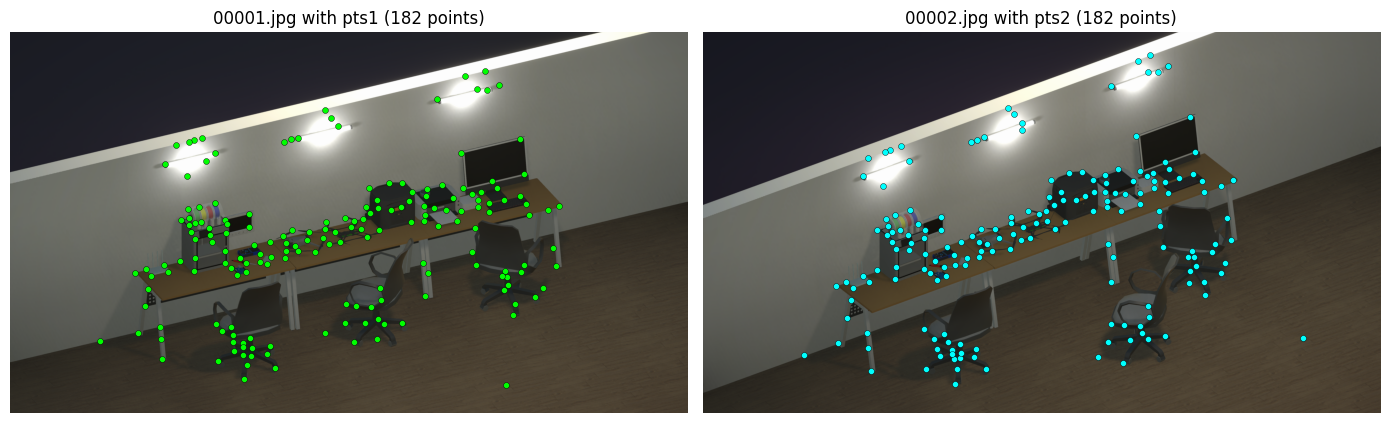

In [367]:
img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

x1, y1 = pts1_scaled[0], pts1_scaled[1]
x2, y2 = pts2_scaled[0], pts2_scaled[1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(img1_rgb)
axes[0].scatter(x1, y1, s=18, c='lime', edgecolors='black', linewidths=0.3)
axes[0].set_title(f"00001.jpg with pts1 ({pts1.shape[1]} points)")
axes[0].axis('off')

axes[1].imshow(img2_rgb)
axes[1].scatter(x2, y2, s=18, c='cyan', edgecolors='black', linewidths=0.3)
axes[1].set_title(f"00002.jpg with pts2 ({pts2.shape[1]} points)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

Estimated F:
 [[ 3.74426381e-08 -3.86955607e-07  2.20229216e-03]
 [ 3.99298462e-07 -7.34130952e-08 -7.13438668e-03]
 [-2.84736953e-03  7.12541922e-03  9.99942684e-01]]
Inliers: 38 / 182
Average distance: 9786.94047358249
Outliers above threshold 500: 28 / 182


(np.float64(-0.5), np.float64(3839.5), np.float64(2159.5), np.float64(-0.5))

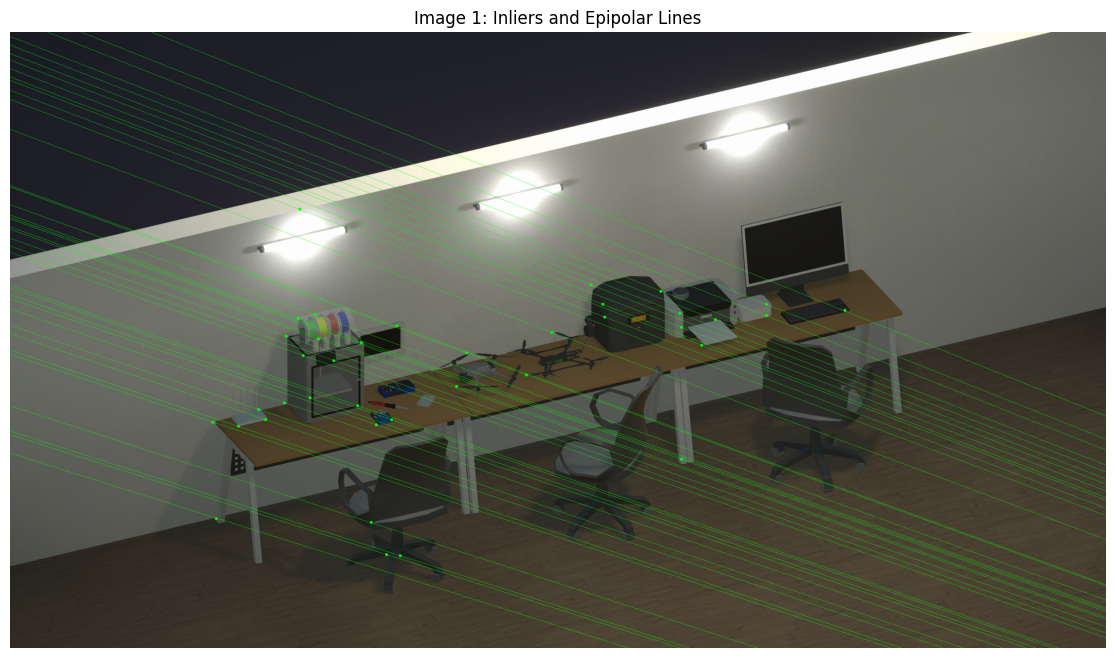

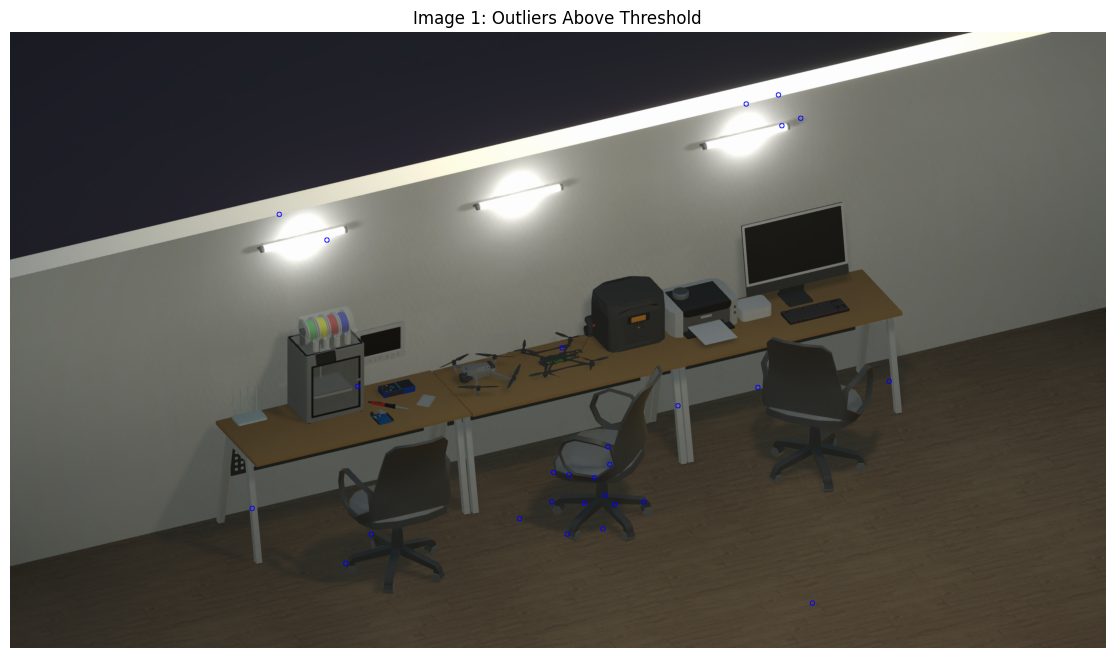

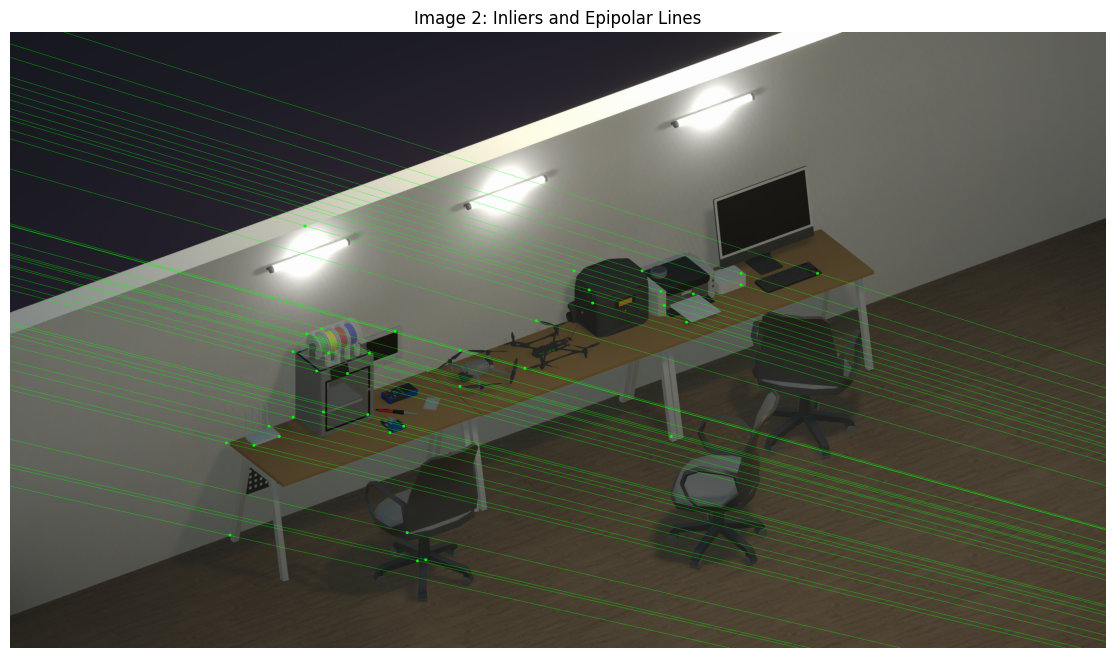

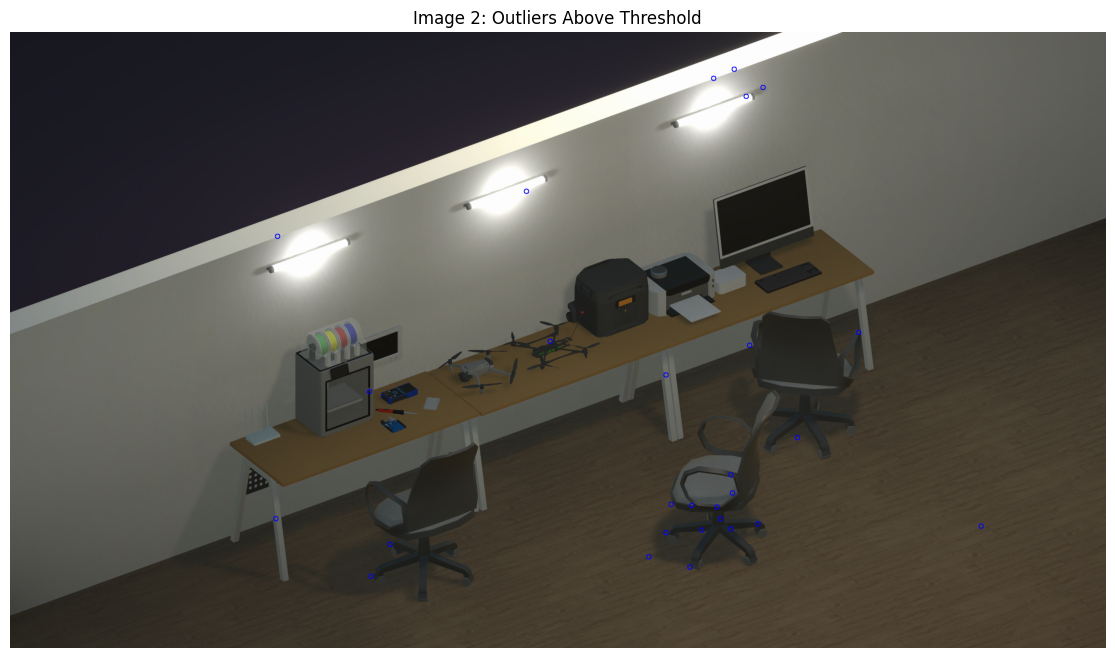

In [368]:
pts1_xy = pts1_scaled[:2, :].T.astype(np.float64)
pts2_xy = pts2_scaled[:2, :].T.astype(np.float64)

F, inliers, average_distance = ransac_eight_point_algorithm(pts1_xy, pts2_xy)

num_inliers = int(np.sum(inliers))

print("Estimated F:\n", F)
print(f"Inliers: {num_inliers} / {len(pts1_xy)}")
print(f"Average distance: {average_distance}")

pts1_in = pts1_xy[inliers]
pts2_in = pts2_xy[inliers]

pts1_h = np.hstack([pts1_in, np.ones((pts1_in.shape[0], 1))])
pts2_h = np.hstack([pts2_in, np.ones((pts2_in.shape[0], 1))])
lines1 = (F.T @ pts2_h.T).T
lines2 = (F @ pts1_h.T).T

img1_epi = draw_epipolar_lines(img1_rgb, lines1, pts1_in)
img2_epi = draw_epipolar_lines(img2_rgb, lines2, pts2_in)

outlier_threshold = 500
all_distances = error_function(F, pts1_xy, pts2_xy)
img1_outliers, outlier_indices = highlight_outliers(img1_rgb, pts1_xy, all_distances, outlier_threshold)
img2_outliers, _ = highlight_outliers(img2_rgb, pts2_xy, all_distances, outlier_threshold)
print(f"Outliers above threshold {outlier_threshold}: {len(outlier_indices)} / {len(pts1_xy)}")

plt.figure(figsize=(16, 8))
plt.imshow(img1_epi)
plt.title("Image 1: Inliers and Epipolar Lines")
plt.axis("off")

plt.figure(figsize=(16, 8))
plt.imshow(img1_outliers)
plt.title("Image 1: Outliers Above Threshold")
plt.axis("off")

plt.figure(figsize=(16, 8))
plt.imshow(img2_epi)
plt.title("Image 2: Inliers and Epipolar Lines")
plt.axis("off")

plt.figure(figsize=(16, 8))
plt.imshow(img2_outliers)
plt.title("Image 2: Outliers Above Threshold")
plt.axis("off")

In [369]:
K = np.array([[1, 0, 0],
              [0, 1, 0],
              [0, 0, 1]], dtype=np.float64)

pts1_normalized = cv2.undistortPoints(pts1_xy.reshape(-1, 1, 2), K, None).reshape(-1, 2)
pts2_normalized = cv2.undistortPoints(pts2_xy.reshape(-1, 1, 2), K, None).reshape(-1, 2)

E, mask = cv2.findEssentialMat(pts1_normalized, pts2_normalized,
                               focal=1,
                               pp=(0, 0),
                               method=cv2.RANSAC,
                               prob=0.999,
                               threshold=1.0)

inliers_essential = mask.ravel() == 1
num_inliers_essential = np.sum(inliers_essential)

pts1_inliers = pts1_normalized[inliers_essential]
pts2_inliers = pts2_normalized[inliers_essential]

_, R, t, _ = cv2.recoverPose(E, pts1_inliers, pts2_inliers, K)

print(f"\nRecovered Pose from Essential Matrix:")
print(f"Rotation R:\n{R}")
print(f"Translation t: {t.ravel()}")

eulerAngles, mtxR, mtxQ, Qx, Qy, Qz = cv2.RQDecomp3x3(R)
print(f"Rotation eulerAngles:\n{eulerAngles}")


Recovered Pose from Essential Matrix:
Rotation R:
[[ 9.87180610e-01  1.59605965e-01 -6.16416144e-04]
 [ 1.59579254e-01 -9.86928470e-01  2.25090175e-02]
 [ 2.98421482e-03 -2.23188329e-02 -9.99746450e-01]]
Translation t: [-0.02232806  0.99969167  0.01086382]
Rotation eulerAngles:
(-178.7211131867908, -0.1709831678928498, 9.182516729162387)


In [370]:
# draw_2d_motion_arrow(img1, R, -t)

In [375]:
from sklearn.cluster import KMeans

k = 10
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = kmeans.fit_predict(pts1_xy[outlier_indices])  # Cluster based on outlier indices

cluster_sizes = np.bincount(labels)
largest_cluster_id = np.argmax(cluster_sizes)
largest_cluster_center = kmeans.cluster_centers_[largest_cluster_id]

print(f"Largest cluster center: {largest_cluster_center}")
print(f"Points in largest cluster: {cluster_sizes[largest_cluster_id]}")

Largest cluster center: [2106.17320503 1600.07142857]
Points in largest cluster: 7


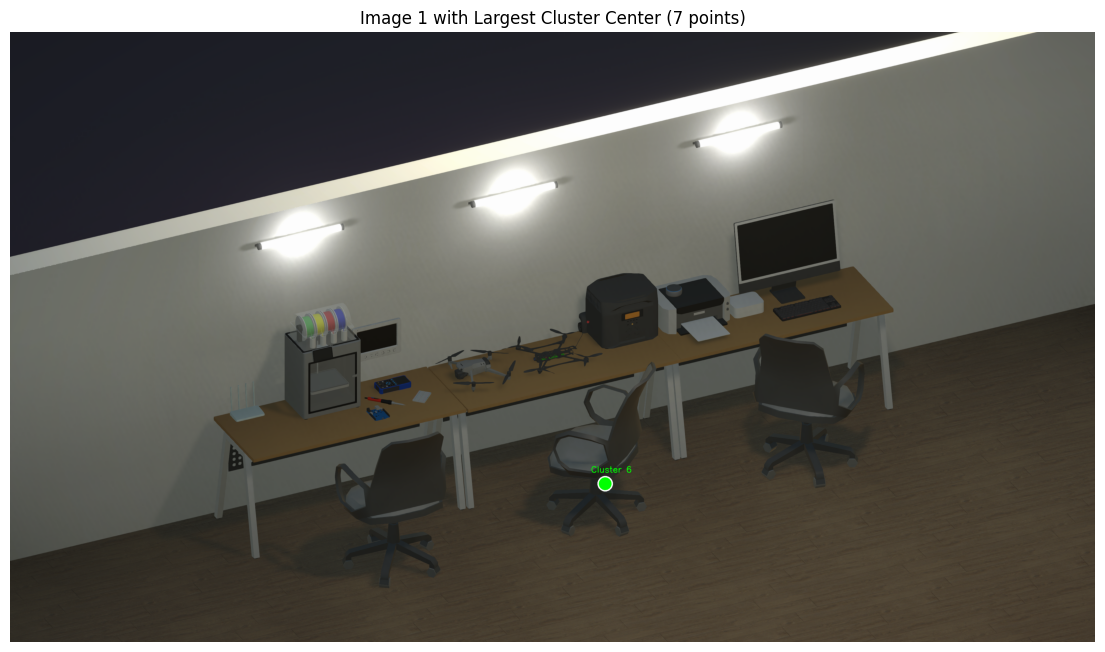

In [376]:
img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB).copy()
center_x = int(round(largest_cluster_center[0]))
center_y = int(round(largest_cluster_center[1]))

cv2.circle(img1_rgb, (center_x, center_y), 25, (0, 255, 0), -1)  # Green filled circle
cv2.circle(img1_rgb, (center_x, center_y), 25, (255, 255, 255), 3)  # White outline

cv2.putText(img1_rgb, f"Cluster {largest_cluster_id}", 
            (center_x - 50, center_y - 40),
            cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

plt.figure(figsize=(14, 10))
plt.imshow(img1_rgb)
plt.title(f"Image 1 with Largest Cluster Center ({cluster_sizes[largest_cluster_id]} points)")
plt.axis('off')
plt.show()